In [1]:
!pip install chromadb
!pip install qdrant-client
!pip install pinecone
!pip install sentence-transformers
!pip install pymorphy3
!pip install pandas
!pip install numpy
!pip install tqdm

  Using cached pymorphy3-2.0.6-py3-none-any.whl.metadata (2.4 kB)
  Using cached dawg2_python-0.9.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached pymorphy3_dicts_ru-2.4.417150.4580142-py2.py3-none-any.whl.metadata (2.0 kB)
Using cached pymorphy3-2.0.6-py3-none-any.whl (53 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.9 MB/s eta 0:00:00


In [2]:
import chromadb
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct

from pinecone import Pinecone, ServerlessSpec

import numpy as np
import pandas as pd
import re
from tqdm import tqdm
import time

from sentence_transformers import SentenceTransformer
import pymorphy3

import json
import matplotlib.pyplot as plt
from google.colab import userdata

In [40]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model_size = 384

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
morph = pymorphy3.MorphAnalyzer()

In [6]:
with open('task_data.json', 'r', encoding='utf-8') as f:
    dataset = json.load(f)

facts = dataset['facts']
queries = dataset['queries']

texts = [f["text"] for f in facts]
topics = [f["topic"] for f in facts]

print(f"Загружено фактов: {len(facts)}")

Загружено фактов: 100


In [7]:
# Функция базовой предобработки текста
def preprocess_raw(text):
    return text

In [8]:
# Функция NLP-предобработки: токенизация + лемматизация
def preprocess_nlp(text):
    words = re.findall(r'\w+', text.lower())
    lemmas = [morph.parse(w)[0].normal_form for w in words]

    return " ".join(lemmas)

In [46]:
# Функция добавления тематических тегов
def preprocess_tags(text, topic):
    tag_map = {
        "temperature":"#жара #температура",
        "humidity":"#влажность #конденсат",
        "raw_material":"#сырье #металл",
        "vibration":"#вибрация #станок",
        "coolant":"#сож #охлаждение",
        "robots":"#роботы #agv",
        "inventory":"#склад #сканер",
        "refrigeration":"#холод #камера",
        "packaging":"#упаковка #коробка",
        "delivery":"#доставка #логистика"
    }

    tags = tag_map.get(topic, "")

    return text + " " + tags

In [47]:
# Функция подготовки текста фактов с использованием выбранного метода предобработки
def prepare_texts(method):
    processed = []
    for f in facts:
        text = f["text"]
        topic = f["topic"]

        if method == "raw":
            processed.append(preprocess_raw(text))
        elif method == "nlp":
            processed.append(preprocess_nlp(text))
        elif method == "tags":
            processed.append(preprocess_tags(text, topic))

    return processed

In [48]:
# Функция подготовки текста запроса
def prepare_query(method, query):
    if method == "raw":
        return preprocess_raw(query)
    elif method == "nlp":
        return preprocess_nlp(query)
    elif method == "tags":
        return query

In [12]:
# Функция вычисления embedding для списка текстов
def embed(texts):
    return model.encode(texts, normalize_embeddings=True)

In [13]:
# Функция оценки точности поиска (= количество релевантных фактов / количество результатов)
def evaluate(returned_ids, expected_topic):
    correct = 0
    for id in returned_ids:
        if topics[id] == expected_topic:
            correct += 1
    return correct / len(returned_ids)

In [24]:
# Функция тестирования ChromaDB: загрузка данных, выполнение запросов, измерение точности и времени
def test_chromadb(texts, embeddings, query_embeddings, method):
    client = chromadb.Client()

    try:
        client.delete_collection(name="facts_chroma")
    except:
        pass

    collection = client.create_collection("facts_chroma")
    ids = [str(i) for i in range(len(texts))]

    collection.add(
        documents=texts,
        embeddings=embeddings.tolist(),
        ids=ids
    )

    scores = []
    times = []
    for q, q_emb in zip(queries, query_embeddings):
        start = time.time()

        results = collection.query(
            query_embeddings=[q_emb.tolist()],
            n_results=10
        )

        elapsed = time.time() - start
        times.append(elapsed)

        returned_ids = [int(i) for i in results["ids"][0]]
        score = evaluate(returned_ids, q["expected_topic"])
        scores.append(score)

    return np.mean(scores), np.mean(times)

In [44]:
# Функция тестирования Qdrant: создание коллекции, загрузка векторов, поиск и измерение точности и времени
def test_qdrant(texts, embeddings, query_embeddings, method, model_size):
    client = QdrantClient(":memory:")
    collection_name = "facts_qdrant"

    client.recreate_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=model_size, distance=Distance.COSINE)
    )

    points = [
        PointStruct(
            id=i,
            vector=emb.tolist(),
            payload={"text": texts[i]}
        ) for i, emb in enumerate(embeddings)
    ]

    client.upsert(collection_name=collection_name, points=points)

    scores = []
    times = []
    for q, q_emb in zip(queries, query_embeddings):
        start = time.time()

        hits = client.query_points(
            collection_name=collection_name,
            query=q_emb,
            limit=10
        ).points

        elapsed = time.time() - start
        times.append(elapsed)

        returned_ids = [hit.id for hit in hits]
        score = evaluate(returned_ids, q["expected_topic"])
        scores.append(score)

    return np.mean(scores), np.mean(times)

In [43]:
# Функция тестирования Pinecone: создание индекса, загрузка данных, выполнение поиска и измерение точности и времени
def test_pinecone(texts, embeddings, query_embeddings, method, model_size):
    pc = Pinecone(api_key=userdata.get('pinecone_api_key'))
    index_name = "facts-pinecone"

    if index_name in pc.list_indexes().names():
        pc.delete_index(index_name)

    pc.create_index(
        name=index_name,
        dimension=model_size,
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

    index = pc.Index(index_name)

    vectors = [
        (str(i), embeddings[i].tolist(), {"text": texts[i]})
        for i in range(len(texts))
    ]

    index.upsert(vectors=vectors)

    scores = []
    times = []

    for q, q_emb in zip(queries, query_embeddings):
        start = time.time()

        results = index.query(
            vector=q_emb.tolist(),
            top_k=10
        )

        elapsed = time.time() - start
        times.append(elapsed)

        returned_ids = [int(m["id"]) for m in results["matches"]]
        score = evaluate(returned_ids, q["expected_topic"])
        scores.append(score)

    return np.mean(scores), np.mean(times)

In [41]:
# Функция тестирования 3х исследуемых баз данных, сбор результатов измерений
def test_all(model_size):
  preprocess_methods = ["raw", "nlp", "tags"]
  results = []

  for m in preprocess_methods:
      print("Testing:", m)
      texts_processed = prepare_texts(m)
      queries_processed = [prepare_query(m, q["query"]) for q in queries]

      fact_embeddings = embed(texts_processed)
      query_embeddings = embed(queries_processed)

      chroma_score, chroma_time = test_chromadb(texts_processed, fact_embeddings, query_embeddings, m)
      qdrant_score, qdrant_time = test_qdrant(texts_processed, fact_embeddings, query_embeddings, m, model_size)
      pinecone_score, pinecone_time = test_pinecone(texts_processed, fact_embeddings, query_embeddings, m, model_size)

      results.append({
          "method": m,
          "chromadb_accuracy": chroma_score,
          "chromadb_time": chroma_time,
          "qdrant_accuracy": qdrant_score,
          "qdrant_time": qdrant_time,
          "pinecone_accuracy": pinecone_score,
          "pinecone_time": pinecone_time
      })

  return results

In [49]:
# Проведение эксперимента с первой embedding моделью "all-MiniLM-L6-v2"
results = test_all(model_size)
df = pd.DataFrame(results)
df

Testing: raw


/tmp/ipykernel_1373/1405104879.py:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Testing: nlp
Testing: tags


,method,chromadb_accuracy,chromadb_time,qdrant_accuracy,qdrant_time,pinecone_accuracy,pinecone_time
0,raw,0.16,0.001859,0.16,0.000688,0.16,0.058133
1,nlp,0.19,0.001279,0.19,0.000598,0.19,0.054141
2,tags,0.30,0.001291,0.30,0.000518,0.30,0.056355


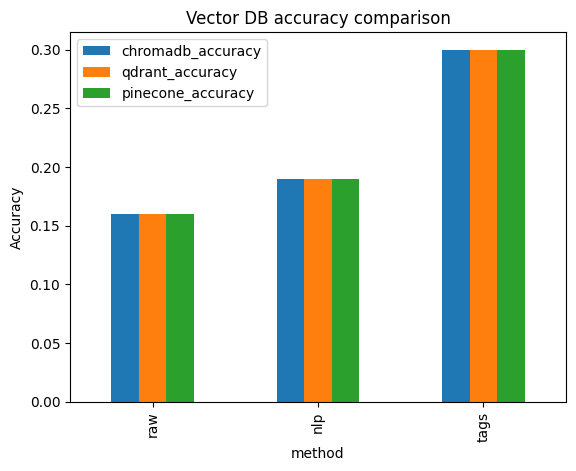

In [50]:
# График точности поиска в исследуемых базах данных при различных алгоритмах предобработки для первого эксперимента
df.set_index("method")[["chromadb_accuracy","qdrant_accuracy","pinecone_accuracy"]].plot(kind="bar")

plt.title("Vector DB accuracy comparison")
plt.ylabel("Accuracy")
plt.show()

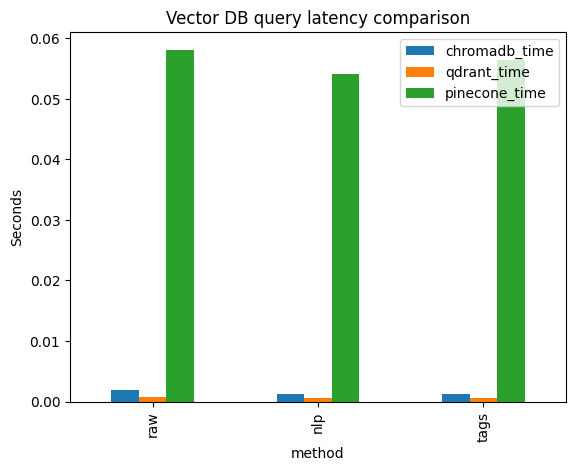

In [51]:
# График времени обработки запроса в исследуемых базах данных при разных алгоритмах предобработки для первого эксперимента
df.set_index("method")[["chromadb_time","qdrant_time","pinecone_time"]].plot(kind="bar")

plt.title("Vector DB query latency comparison")
plt.ylabel("Seconds")
plt.show()

In [52]:
# Проведение эксперимента со второй embedding моделью "intfloat/multilingual-e5-base"
model = SentenceTransformer("intfloat/multilingual-e5-base")
model_size = 768
results = test_all(model_size)

df = pd.DataFrame(results)
df

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Testing: raw


/tmp/ipykernel_1373/1405104879.py:6: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


Testing: nlp
Testing: tags


,method,chromadb_accuracy,chromadb_time,qdrant_accuracy,qdrant_time,pinecone_accuracy,pinecone_time
0,raw,0.44,0.001512,0.44,0.000831,0.44,0.048709
1,nlp,0.43,0.001403,0.43,0.000951,0.44,0.052210
2,tags,0.66,0.001424,0.66,0.001009,0.65,0.055412


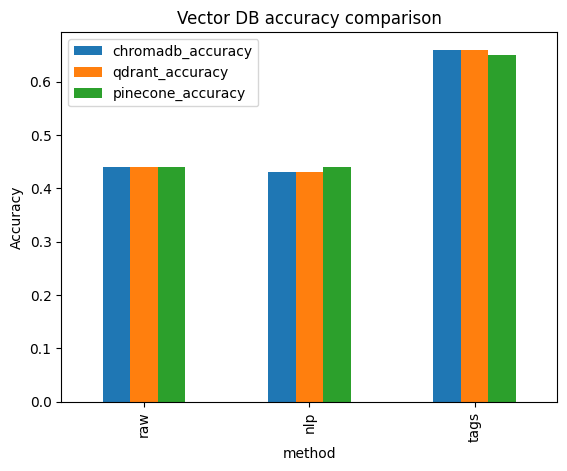

In [53]:
# График точности поиска в исследуемых базах данных при различных алгоритмах предобработки для второго эксперимента
df.set_index("method")[["chromadb_accuracy","qdrant_accuracy","pinecone_accuracy"]].plot(kind="bar")

plt.title("Vector DB accuracy comparison. 1st ")
plt.ylabel("Accuracy")
plt.show()

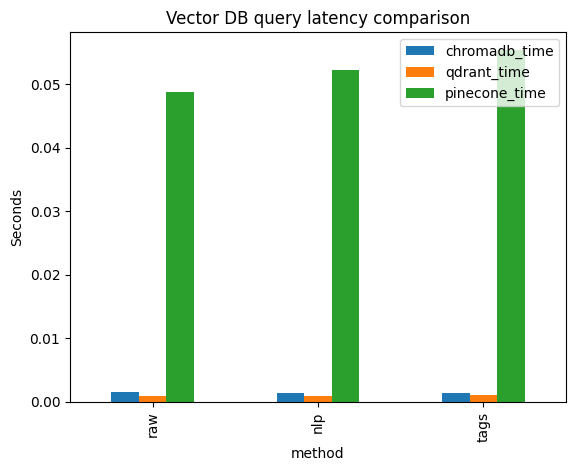

In [54]:
# График времени обработки запроса в исследуемых базах данных при разных алгоритмах предобработки для второго эксперимента
df.set_index("method")[["chromadb_time","qdrant_time","pinecone_time"]].plot(kind="bar")

plt.title("Vector DB query latency comparison")
plt.ylabel("Seconds")
plt.show()